# Load shit

In [48]:
import os
from pathlib import Path
import sys

HOMEDIR = Path("../../..")
DATADIR = HOMEDIR / "data"
SRCDIR = HOMEDIR / "src"
if str(SRCDIR) not in sys.path:
    sys.path.append(str(SRCDIR))

import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [36]:
adata = sc.datasets.pbmc3k()
adata.layers["counts"] = adata.X.copy()

# QC

In [45]:
from single_cell.preprocess import Filter_QC, Filter_GeneGroup, Filter_Doublet, Normalize, FindVariableGenes, PCA, Visualize, Cluster

In [37]:
adata.obs = adata.obs.dropna(axis=1, how="any")
Filter_QC(adata)
Filter_GeneGroup(adata, "ribo", "^Rps|^Rpl", perc_threshold=10)
Filter_GeneGroup(adata, "mito", "^mt", perc_threshold=10)
Filter_GeneGroup(adata, "unknown", "^ENMUSG|^Gm[0-9]|Rik")
Normalize(adata)
FindVariableGenes(adata, "seurat_v3", n_features=200)

Cells removed by gene/count filters: 3 (0.11%)
Cells with >10% ribo genes: 0 (0.00%)
Cells with >10% mito genes: 0 (0.00%)
Saving normalized counts in layer 'normalized'.
Finding HVGs...


AnnData object with n_obs × n_vars = 2697 × 11139
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'gene_ids', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'mito', 'unknown', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'methods', 'log1p', 'hvg'
    layers: 'counts', 'normalized'

Setting layer to normalized.
Starting PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA-hvg].


/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)



---------------------------------------------
begin neighbors & UMAP at Fri Jun 26 14:44:23 2026, (total: 1:18:59.941748)

Starting UMAP...


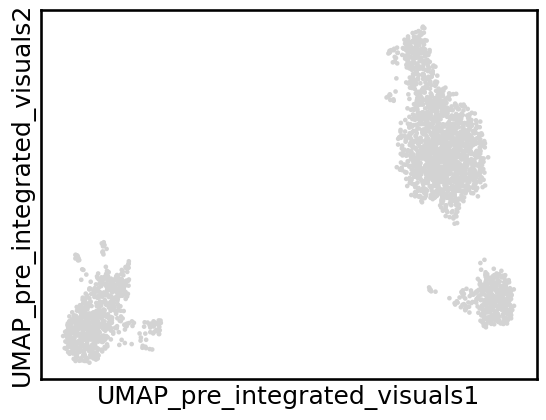

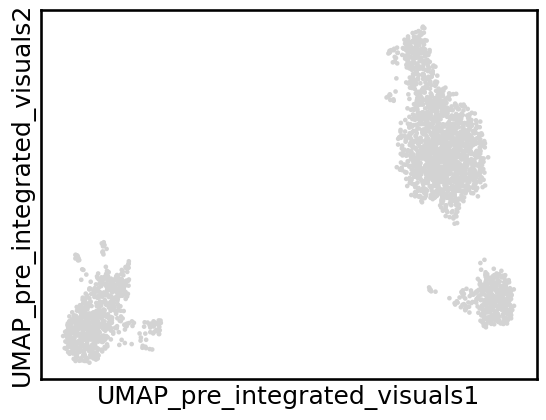

Running NN Backend on high-dimensional data. Nearest-neighbor search may be slow!


finished neighbors & UMAP in 0:00:04.869821


---------------------------------------------
begin LocalMAP at Fri Jun 26 14:44:28 2026, (total: 1:19:04.812622)



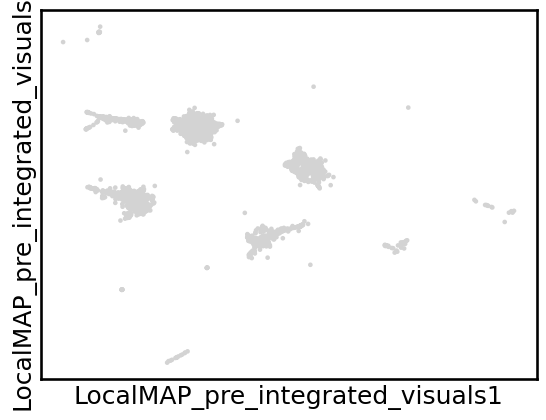

finished LocalMAP in 0:00:02.346602


---------------------------------------------
begin PaCMAP at Fri Jun 26 14:44:30 2026, (total: 1:19:07.159349)



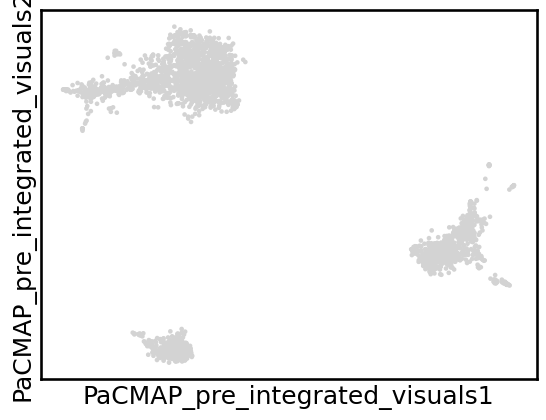

finished PaCMAP in 0:00:02.106142



AnnData object with n_obs × n_vars = 2697 × 11139
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'gene_ids', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'mito', 'unknown', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'methods', 'log1p', 'hvg', 'PCA-hvg', 'neighbors_pre_integrated_visuals', 'UMAP_pre_integrated_visuals'
    obsm: 'PCA-hvg', 'UMAP_pre_integrated_visuals', 'LocalMAP_pre_integrated_visuals', 'PaCMAP_pre_integrated_visuals'
    varm: 'PCA-hvg'
    layers: 'counts', 'normalized'
    obsp: 'neighbors_pre_integ

In [40]:
PCA(adata, "highly_variable", "PCA-hvg")
Visualize(adata, "pre_integrated_visuals", obsm="PCA-hvg", pacmap=True, localmap=True)

In [46]:
adata.uns["neighbors_pre_integrated_visuals"]

{'connectivities_key': 'neighbors_pre_integrated_visuals_connectivities',
 'distances_key': 'neighbors_pre_integrated_visuals_distances',
 'params': {'n_neighbors': 15,
  'method': 'umap',
  'random_state': 0,
  'metric': 'euclidean',
  'use_rep': 'PCA-hvg'}}

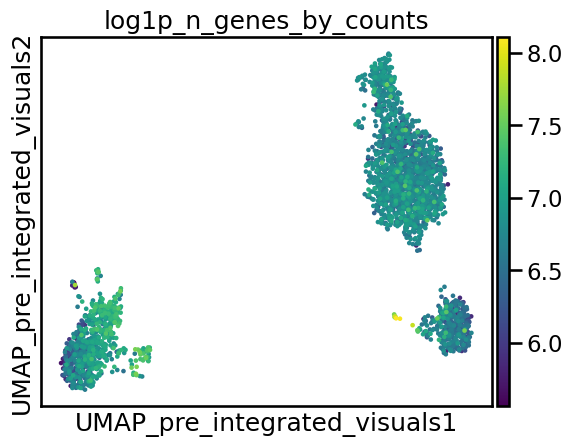

In [43]:
sc.pl.embedding(adata, "UMAP_pre_integrated_visuals", color="log1p_n_genes_by_counts")


---------------------------------------------
begin Clustering at Fri Jun 26 14:48:16 2026, (total: 1:22:53.417555)



Clustering: 100%|██████████| 9/9 [00:00<00:00, 10.75it/s]
/mnt/DATA/home/jbalcerek/spatial_seq/src/notebooks/joanna/../../../src/single_cell/preprocess.py:635: UserWarning: You’re trying to run this on 11139 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  tmp_adata = sc.pp.neighbors(adata, use_rep=int_key, copy=True)
Calculating graph connectivity:   0%|          | 0/9 [00:00<?, ?it/s]/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/mnt/DATA/home/jbalcerek/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).va

finished Clustering in 0:00:01.945786



AnnData object with n_obs × n_vars = 2697 × 11139
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'test_clustering_0.1', 'test_clustering_0.2', 'test_clustering_0.3', 'test_clustering_0.4', 'test_clustering_0.5', 'test_clustering_0.6', 'test_clustering_0.7', 'test_clustering_0.8', 'test_clustering_0.9'
    var: 'gene_ids', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'mito', 'unknown', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'methods', 'log1p', 'hvg', 'PCA-hvg', 'neighbors_pre_integrated_visuals', 'UMAP_pre_integrated_visual

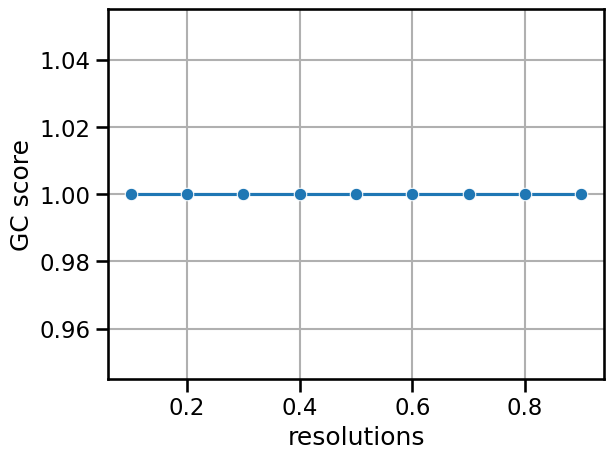

In [49]:
Cluster(adata, "neighbors_pre_integrated_visuals", "test_clustering", np.arange(1,10)/10)

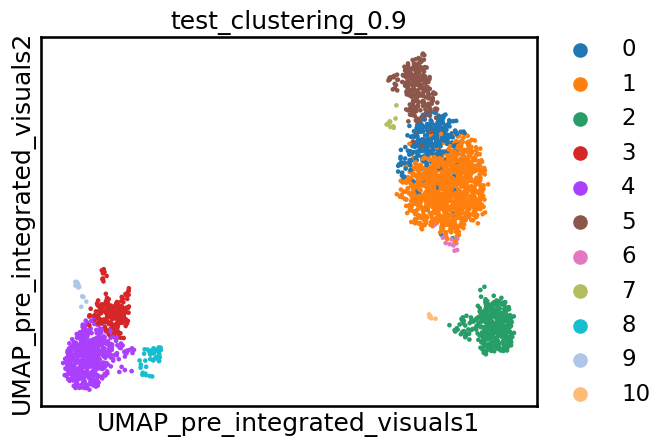

In [55]:
sc.pl.embedding(adata, "UMAP_pre_integrated_visuals", color="test_clustering_0.9")